### Phase 4: Backtesting-Strategie
Wir plotten zunächst die Regime-Wahrscheinlichkeiten der Modelle sowie der tatsächlichen Modell-Signale.

Anschließend testen wir den Erfolg einer Investition in Abhängigkeit zum gewählten Modell und den unten beschriebenen Regeln.

*   **Regel:**
    *   Wenn Modell sagt "Bull": 100% Aktien (S&P 500).
    *   Wenn Modell sagt "Bear": 100% Bonds oder Cash.
*   **Transaktionskosten:** Integriere realistische Kosten (z.B. 0,1% pro Trade), da ML-Modelle oft zu nervös hin- und herschalten ("Churning").

In [1]:
import pandas as pd

# Daten aus dem data-Ordner laden
test_df = pd.read_parquet("../data/03_test_df_data.parquet")

Berechne Backtest für: HMM
Berechne Backtest für: MS_Univariate
Berechne Backtest für: MS_Exo
Berechne Backtest für: LSTM


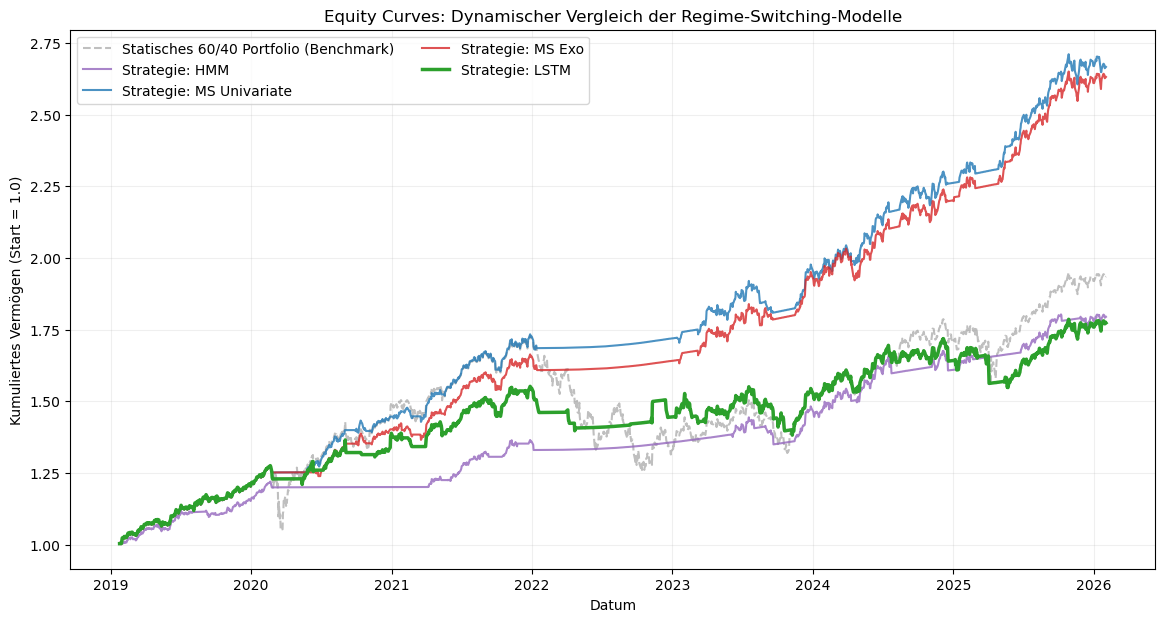

Backtesting abgeschlossen. 4 Strategien wurden berechnet.


In [2]:
# --- 5. Dynamisches Backtesting (Automatisierter Vergleich aller Modelle) ---

import matplotlib.pyplot as plt
import numpy as np

def backtest(df, signal_col):
    """
    Berechnet die kumulierte Rendite einer Strategie.
    Bull (0): Investiert im 60/40 Portfolio
    Bear (1): Investiert im Geldmarkt (Cash_Returns)
    """
    # Signal um 1 Tag verschieben zur Vermeidung von Look-ahead Bias
    # Wir handeln heute basierend auf dem Signal, das gestern vorlag.
    trading_signal = df[signal_col].shift(1).fillna(0)
    
    # Logik: Wenn Signal 0 -> Portfolio-Return, sonst Cash-Return
    strategy_returns = np.where(trading_signal == 0, 
                                df['Returns'], 
                                df['Cash_Returns'])
    
    # Kumulierte Rendite berechnen (Startwert 1.0)
    return (1 + strategy_returns).cumprod()

# 1. Alle verfügbaren Modelle dynamisch identifizieren (anhand der _Signal Endung)
signal_cols = [col for col in test_df.columns if col.endswith('_Signal')]

# 2. Ergebnisse-DataFrame initialisieren
backtesting_results = pd.DataFrame(index=test_df.index)

# Benchmark berechnen (Buy & Hold des 60/40 Portfolios)
backtesting_results['Buy_Hold'] = (1 + test_df['Returns']).cumprod()

# Alle erkannten Modelle dynamisch backtesten
for sig_col in signal_cols:
    # Modellnamen extrahieren (alles vor dem letzten '_Signal')
    model_name = sig_col.rsplit('_', 1)[0]
    
    print(f"Berechne Backtest für: {model_name}")
    backtesting_results[model_name] = backtest(test_df, sig_col)

# 3. Dynamische Visualisierung
plt.figure(figsize=(14, 7))

# Vordefinierte Farben für Konsistenz (optional)
color_map = {
    'Buy_Hold': 'gray',
    'MS_Univariate': 'tab:blue',
    'MS_Exo': 'tab:red',
    'HMM': 'tab:purple',
    'LSTM': 'tab:green'
}

# Plotte erst die Benchmark (Buy & Hold)
plt.plot(backtesting_results['Buy_Hold'], 
         label='Statisches 60/40 Portfolio (Benchmark)', 
         color=color_map.get('Buy_Hold', 'gray'), 
         alpha=0.5, linestyle='--')

# Plotte alle berechneten Strategien
for col in backtesting_results.columns:
    if col == 'Buy_Hold':
        continue
    
    # Stil-Anpassungen
    color = color_map.get(col, None) # Nimmt Standardfarbe falls Modell unbekannt
    linewidth = 2.5 if col == 'LSTM' else 1.5
    alpha = 1.0 if col == 'LSTM' else 0.8
    
    plt.plot(backtesting_results[col], 
             label=f'Strategie: {col.replace("_", " ")}', 
             color=color, linewidth=linewidth, alpha=alpha)

plt.title("Equity Curves: Dynamischer Vergleich der Regime-Switching-Modelle")
plt.xlabel("Datum")
plt.ylabel("Kumuliertes Vermögen (Start = 1.0)")
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.2)

# Equity Curve persistieren
plt.savefig('../assets/equity_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Daten für das nächste Notebook (Evaluation) speichern
backtesting_results.to_parquet("../data/04_backtesting_results_data.parquet")

print(f"Backtesting abgeschlossen. {len(signal_cols)} Strategien wurden berechnet.")

#--- Wir erhalten in diesem Schritt neben df und test_df backtesting_results mit kumulierten Werten ----

In [3]:
# --- Performance & Drawdown Zusammenfassung ---

print("\n--- PERFORMANCE & DRAWDOWN ZUSAMMENFASSUNG ---")

summary_stats = []

for col in backtesting_results.columns:
    series = backtesting_results[col]
    
    # Finale Werte berechnen
    final_val = series.iloc[-1]
    total_ret = (final_val - 1) * 100
    
    # Max Drawdown berechnen
    roll_max = series.cummax()
    drawdown = series / roll_max - 1.0
    mdd = drawdown.min() * 100
    
    summary_stats.append({
        'Strategie': col,
        'Final Wealth': f"{final_val:.4f}",
        'Total Return': f"{total_ret:+.2f}%",
        'Max Drawdown': f"{mdd:.2f}%"
    })

# In DataFrame umwandeln
performance_summary_df = pd.DataFrame(summary_stats).set_index('Strategie')

# Als Markdown persistieren
performance_summary_df.to_markdown('../assets/performance_summary.md')

print("Zusammenfassung erfolgreich unter ../assets/performance_summary.md gespeichert.")

# Im Notebook anzeigen
display(performance_summary_df)


--- PERFORMANCE & DRAWDOWN ZUSAMMENFASSUNG ---
Zusammenfassung erfolgreich unter ../assets/performance_summary.md gespeichert.


,Final Wealth,Total Return,Max Drawdown
Strategie,,,
Buy_Hold,1.9352,+93.52%,-27.10%
HMM,1.7944,+79.44%,-6.53%
MS_Univariate,2.6662,+166.62%,-5.80%
MS_Exo,2.6312,+163.12%,-5.44%
LSTM,1.7731,+77.31%,-10.97%


In [4]:
output_path = "../data/04_backtesting_results_data.parquet"

# Speichern als Parquet
backtesting_results.to_parquet(output_path)

print(f"Dataframe erfolgreich unter {output_path} gespeichert.")

Dataframe erfolgreich unter ../data/04_backtesting_results_data.parquet gespeichert.
